# Weight sensitivity for the reproducibility index

The composite score is `R = sqrt(R_c · R_s)` with two convex weight vectors hardcoded in `ara_pipeline.repro_scoring`:

- **Layer weights** (content): `source = 0.30, process = 0.40, sink = 0.30`
- **Structural weights** (wiring): `sources_consumed = 0.25, sinks_produced = 0.25, resolved_inputs = 0.20, source_to_sink_reachability = 0.15, lwcc_fraction = 0.15`

Reviewer concern: the weights look hardcoded, justify or ablate. This notebook quantifies how much `R` (and the resulting per-paper ranking) actually depends on them, using **all consistency runs** under:

- `data/experiments/consistency_checks/rescience_c` (hosted Gemini / GPT-4.1)
- `data/experiments/consistency_checks/rescience_c_local_models` (offline Qwen3)

Three perturbation schemes are evaluated:

1. **Uniform** — replace either weight vector by `1/k`. Worst-case null baseline a reviewer would propose.
2. **Leave-one-out** — drop each component in turn and renormalize. Per-component contribution.
3. **Dirichlet** perturbations around the default with concentration `α ∈ {5, 20, 100}` and 200 draws per `α`. Continuous robustness sweep.

Stability is reported at three levels: per-profile score deltas, per-paper mean deltas, and Spearman rank correlation between default and perturbed paper rankings.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

REPO = Path.cwd().resolve()
while REPO != REPO.parent and not (REPO / "src" / "ara_pipeline").is_dir():
    REPO = REPO.parent
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from ara_pipeline.repro_scoring import (
    LAYER_W,
    STRUCT_W,
    build_graph,
    parse_stem,
    wiring_metrics,
)

PROFILE_DIRS = [
    REPO / "data" / "experiments" / "consistency_checks" / "rescience_c",
    REPO / "data" / "experiments" / "consistency_checks" / "rescience_c_local_models",
]
for d in PROFILE_DIRS:
    assert d.is_dir(), f"missing: {d}"
    print(d.relative_to(REPO), "->", sum(1 for _ in d.glob('*.profile.json')), 'profiles')

STRUCT_KEYS = list(STRUCT_W.keys())
LAYER_KEYS = list(LAYER_W.keys())
print('default LAYER_W :', LAYER_W)
print('default STRUCT_W:', STRUCT_W)

data/experiments/consistency_checks/rescience_c -> 2304 profiles
data/experiments/consistency_checks/rescience_c_local_models -> 433 profiles
default LAYER_W : {'source': 0.3, 'process': 0.4, 'sink': 0.3}
default STRUCT_W: {'sources_consumed_ratio': 0.25, 'sinks_produced_ratio': 0.25, 'resolved_input_ratio': 0.2, 'source_to_sink_reachability': 0.15, 'lwcc_fraction': 0.15}


## 1. Cache wiring metrics + per-layer means

Reweighting only changes the linear combination, not the underlying quantities. Cache `wiring_metrics(g)` and per-layer `reproducibility_score` means once per profile so every scheme reuses them.

In [2]:
def layer_mean(items):
    if not items:
        return None
    return sum(int(it.get('reproducibility_score', 0)) for it in items) / len(items) / 100.0


records = []
for d in PROFILE_DIRS:
    for path in sorted(d.glob('*.profile.json')):
        info = parse_stem(path.stem.removesuffix('.profile'))
        if info is None:
            continue
        try:
            profile = json.loads(path.read_text(encoding='utf-8'))
        except json.JSONDecodeError:
            continue
        wm = wiring_metrics(build_graph(profile))
        records.append({
            'paper': info.paper,
            'model': info.model,
            'temperature': info.temperature,
            'sample': info.sample,
            'src_dir': d.name,
            'layer_source':  layer_mean(profile.get('nodes_source', [])),
            'layer_process': layer_mean(profile.get('nodes_process', [])),
            'layer_sink':    layer_mean(profile.get('nodes_sink', [])),
            **{f's_{k}': wm[k] for k in STRUCT_KEYS},
        })

cache = pd.DataFrame.from_records(records)
print('profiles loaded :', len(cache))
print('papers          :', cache['paper'].nunique())
print('models          :', sorted(cache['model'].unique()))
cache.head()

profiles loaded : 2737
papers          : 10
models          : ['gemini-2.5-flash', 'gemini-2.5-pro', 'gemini-3-flash-preview', 'gemini-3.1-pro-preview', 'gpt-4.1', 'qwen3-32b', 'qwen3-8b']


,paper,model,temperature,sample,src_dir,layer_source,layer_process,layer_sink,s_sources_consumed_ratio,s_sinks_produced_ratio,s_resolved_input_ratio,s_source_to_sink_reachability,s_lwcc_fraction
0,2017_01_article.pdf,gemini-2.5-flash,0.0,10,rescience_c,1.0,0.671429,1.0,1.0,0.347826,1.0,0.347826,0.516129
1,2017_01_article.pdf,gemini-2.5-pro,0.0,10,rescience_c,NaN,0.250000,0.7,0.0,1.000000,1.0,0.000000,1.000000
2,2017_01_article.pdf,gemini-3-flash-preview,0.0,10,rescience_c,NaN,0.630000,1.0,0.0,1.000000,1.0,0.000000,1.000000
3,2017_01_article.pdf,gemini-3.1-pro-preview,0.0,10,rescience_c,NaN,0.833333,0.9,0.0,1.000000,1.0,0.000000,1.000000
4,2017_01_article.pdf,gpt-4.1,0.0,10,rescience_c,NaN,0.842857,0.9,0.0,1.000000,1.0,0.000000,1.000000


## 2. Reweighted scoring helper

`score_with_weights(layer_w, struct_w)` returns a `(R_c, R_s, R)` DataFrame indexed like `cache`. Layer means that are `None` (empty layer) are excluded with the remaining weights renormalised, matching `content_score` in `repro_scoring.py`.

In [3]:
_LAYER_COLS = {'source': 'layer_source', 'process': 'layer_process', 'sink': 'layer_sink'}


def score_with_weights(layer_w: dict, struct_w: dict) -> pd.DataFrame:
    layer_w = {k: float(layer_w.get(k, 0.0)) for k in LAYER_KEYS}
    struct_w = {k: float(struct_w.get(k, 0.0)) for k in STRUCT_KEYS}
    assert math.isclose(sum(layer_w.values()), 1.0, abs_tol=1e-9)
    assert math.isclose(sum(struct_w.values()), 1.0, abs_tol=1e-9)

    rs = sum(struct_w[k] * cache[f's_{k}'] for k in STRUCT_KEYS)

    layer_arr = pd.DataFrame({k: cache[col] for k, col in _LAYER_COLS.items()})
    weight_arr = pd.DataFrame({k: layer_arr[k].notna().astype(float) * layer_w[k] for k in LAYER_KEYS})
    weight_sum = weight_arr.sum(axis=1).replace(0.0, np.nan)
    rc = (layer_arr.fillna(0.0) * weight_arr).sum(axis=1) / weight_sum
    rc = rc.fillna(0.0)

    r = np.sqrt(np.clip(rs, 0, None) * np.clip(rc, 0, None))
    return pd.DataFrame({'R_c': rc, 'R_s': rs, 'R': r}, index=cache.index)


default = score_with_weights(LAYER_W, STRUCT_W)
default.describe()

,R_c,R_s,R
count,2737.000000,2737.000000,2737.000000
mean,0.705946,0.717932,0.696184
std,0.166259,0.237417,0.174968
min,0.182143,0.006818,0.039167
25%,0.580769,0.600000,0.614673
50%,0.717812,0.750992,0.714205
75%,0.853333,0.925000,0.813723
max,1.000000,1.000000,1.000000


## 3. Discrete schemes — uniform + leave-one-out

Each scheme renormalises so the remaining weights sum to 1. Leave-one-out is reported separately per layer / per structural metric.

In [4]:
def renorm(d):
    s = sum(d.values())
    return {k: v / s for k, v in d.items()}


schemes: dict[str, tuple[dict, dict]] = {
    'default':       (LAYER_W, STRUCT_W),
    'uniform_layer': ({k: 1 / 3 for k in LAYER_KEYS}, STRUCT_W),
    'uniform_struct': (LAYER_W, {k: 1 / len(STRUCT_KEYS) for k in STRUCT_KEYS}),
    'uniform_both':  ({k: 1 / 3 for k in LAYER_KEYS}, {k: 1 / len(STRUCT_KEYS) for k in STRUCT_KEYS}),
}
for k in LAYER_KEYS:
    schemes[f'loo_layer:{k}'] = (renorm({kk: v for kk, v in LAYER_W.items() if kk != k}), STRUCT_W)
for k in STRUCT_KEYS:
    schemes[f'loo_struct:{k}'] = (LAYER_W, renorm({kk: v for kk, v in STRUCT_W.items() if kk != k}))

score_table = {name: score_with_weights(lw, sw) for name, (lw, sw) in schemes.items()}
ref = score_table['default']['R']
rows = []
for name, df in score_table.items():
    delta = df['R'] - ref
    rows.append({
        'scheme': name,
        'R_mean': df['R'].mean(),
        '|ΔR|_mean': delta.abs().mean(),
        '|ΔR|_p95': np.quantile(delta.abs(), 0.95),
        '|ΔR|_max': delta.abs().max(),
    })
summary = pd.DataFrame(rows).set_index('scheme').round(4)
summary

,R_mean,|ΔR|_mean,|ΔR|_p95,|ΔR|_max
scheme,,,,
default,0.6962,0.0000,0.0000,0.0000
uniform_layer,0.6914,0.0085,0.0230,0.0343
uniform_struct,0.6922,0.0071,0.0282,0.0488
uniform_both,0.6875,0.0141,0.0365,0.0584
loo_layer:source,0.7291,0.0474,0.1371,0.1584
loo_layer:process,0.6638,0.0561,0.1540,0.5237
loo_layer:sink,0.6825,0.0261,0.0705,0.2808
loo_struct:sources_consumed_ratio,0.7187,0.0428,0.1124,0.1774
loo_struct:sinks_produced_ratio,0.6798,0.0349,0.0888,0.2363


## 4. Per-paper ranking stability

For each scheme, average `R` per paper across all models / temperatures / samples, rank papers, and compare to the default ranking via Spearman ρ. ρ close to 1 means the same papers are flagged as more / less reproducible regardless of weighting.

In [5]:
def per_paper_mean(R: pd.Series) -> pd.Series:
    return R.groupby(cache['paper']).mean()


ranking = {name: per_paper_mean(df['R']) for name, df in score_table.items()}
ref_paper = ranking['default']

rho_rows = []
for name, series in ranking.items():
    rho, _ = spearmanr(ref_paper, series)
    rho_rows.append({'scheme': name, 'spearman_rho_vs_default': rho})
rho_table = pd.DataFrame(rho_rows).set_index('scheme').round(4)
rho_table

,spearman_rho_vs_default
scheme,
default,1.0000
uniform_layer,0.9758
uniform_struct,0.9879
uniform_both,0.9515
loo_layer:source,0.8788
loo_layer:process,0.8909
loo_layer:sink,0.9030
loo_struct:sources_consumed_ratio,0.8424
loo_struct:sinks_produced_ratio,0.9758


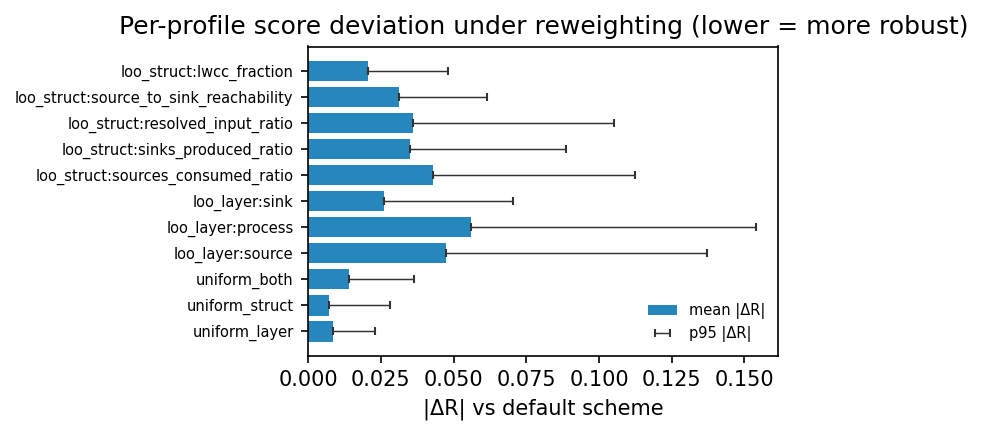

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 3.0), dpi=150)
schemes_to_plot = [s for s in summary.index if s != 'default']
y = np.arange(len(schemes_to_plot))
ax.barh(y, summary.loc[schemes_to_plot, '|ΔR|_mean'], color='#0072B2', alpha=0.85, label='mean |ΔR|')
ax.errorbar(
    summary.loc[schemes_to_plot, '|ΔR|_mean'], y,
    xerr=[np.zeros(len(y)), summary.loc[schemes_to_plot, '|ΔR|_p95'] - summary.loc[schemes_to_plot, '|ΔR|_mean']],
    fmt='none', ecolor='#333', elinewidth=0.7, capsize=2, label='p95 |ΔR|',
)
ax.set_yticks(y)
ax.set_yticklabels(schemes_to_plot, fontsize=7)
ax.set_xlabel('|ΔR| vs default scheme')
ax.set_title('Per-profile score deviation under reweighting (lower = more robust)')
ax.legend(loc='lower right', fontsize=7, frameon=False)
fig.tight_layout()
plt.show()

## 5. Continuous Dirichlet perturbation

Sample weights from `Dir(α · default)` so the expectation matches the default; large `α` keeps draws tight, small `α` makes them diffuse. Report median |ΔR|, 95th percentile, and Spearman ρ of paper rankings against the default.

In [7]:
RNG = np.random.default_rng(42)
ALPHAS = [5.0, 20.0, 100.0]
K = 200

layer_default = np.array([LAYER_W[k] for k in LAYER_KEYS])
struct_default = np.array([STRUCT_W[k] for k in STRUCT_KEYS])

rows = []
for alpha in ALPHAS:
    abs_dev = []
    rhos = []
    for _ in range(K):
        lw_arr = RNG.dirichlet(alpha * layer_default)
        sw_arr = RNG.dirichlet(alpha * struct_default)
        lw = dict(zip(LAYER_KEYS, lw_arr))
        sw = dict(zip(STRUCT_KEYS, sw_arr))
        df = score_with_weights(lw, sw)
        abs_dev.append(np.abs(df['R'].values - ref.values))
        rho, _ = spearmanr(ref_paper, per_paper_mean(df['R']))
        rhos.append(rho)
    abs_dev = np.concatenate(abs_dev)
    rows.append({
        'alpha': alpha,
        '|ΔR|_median': np.median(abs_dev),
        '|ΔR|_p95': np.quantile(abs_dev, 0.95),
        'spearman_mean': np.mean(rhos),
        'spearman_min':  np.min(rhos),
    })
dirichlet_summary = pd.DataFrame(rows).round(4)
dirichlet_summary

,alpha,|ΔR|_median,|ΔR|_p95,spearman_mean,spearman_min
0,5.0,0.0515,0.1900,0.8876,0.5515
1,20.0,0.0238,0.0942,0.9507,0.8182
2,100.0,0.0116,0.0426,0.9804,0.9152


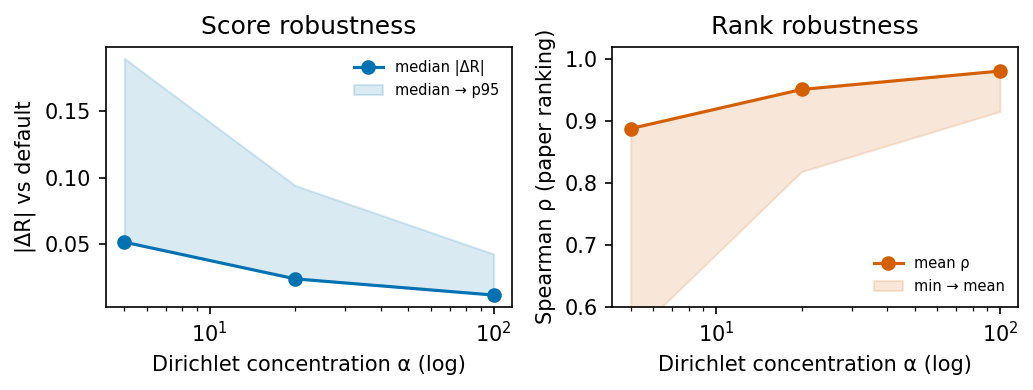

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.7), dpi=150)
ax_l, ax_r = axes

ax_l.plot(dirichlet_summary['alpha'], dirichlet_summary['|ΔR|_median'], 'o-', color='#0072B2', label='median |ΔR|')
ax_l.fill_between(
    dirichlet_summary['alpha'],
    dirichlet_summary['|ΔR|_median'],
    dirichlet_summary['|ΔR|_p95'],
    alpha=0.15, color='#0072B2', label='median → p95',
)
ax_l.set_xscale('log')
ax_l.set_xlabel('Dirichlet concentration α (log)')
ax_l.set_ylabel('|ΔR| vs default')
ax_l.set_title('Score robustness')
ax_l.legend(fontsize=7, frameon=False)

ax_r.plot(dirichlet_summary['alpha'], dirichlet_summary['spearman_mean'], 'o-', color='#D55E00', label='mean ρ')
ax_r.fill_between(
    dirichlet_summary['alpha'],
    dirichlet_summary['spearman_min'],
    dirichlet_summary['spearman_mean'],
    alpha=0.15, color='#D55E00', label='min → mean',
)
ax_r.set_xscale('log')
ax_r.set_xlabel('Dirichlet concentration α (log)')
ax_r.set_ylabel('Spearman ρ (paper ranking)')
ax_r.set_title('Rank robustness')
ax_r.set_ylim(0.6, 1.02)
ax_r.legend(fontsize=7, frameon=False)

fig.tight_layout()
plt.show()